<a href="https://colab.research.google.com/github/karthikvanka-commits/ML_LAB/blob/main/Experimennt6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns: ['StudentID', 'CGPA', 'Internships', 'Projects', 'AptitudeTestScore', 'CommunicationSkill', 'Placed']

First 5 rows:
   StudentID  CGPA  Internships  Projects  AptitudeTestScore  \
0          1  6.87            2         2                 57   
1          2  9.75            1         2                 95   
2          3  8.66            1         0                 71   
3          4  7.99            3         2                 74   
4          5  5.78            1         4                 91   

   CommunicationSkill  Placed  
0                   8       0  
1                   1       1  
2                   6       1  
3                   8       1  
4                   5       1  

Accuracy: 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.75      0.60         4
           1       0.75      0.50      0.60         6

    accuracy                           0.60        10
   macro avg       0.62      0.62      0

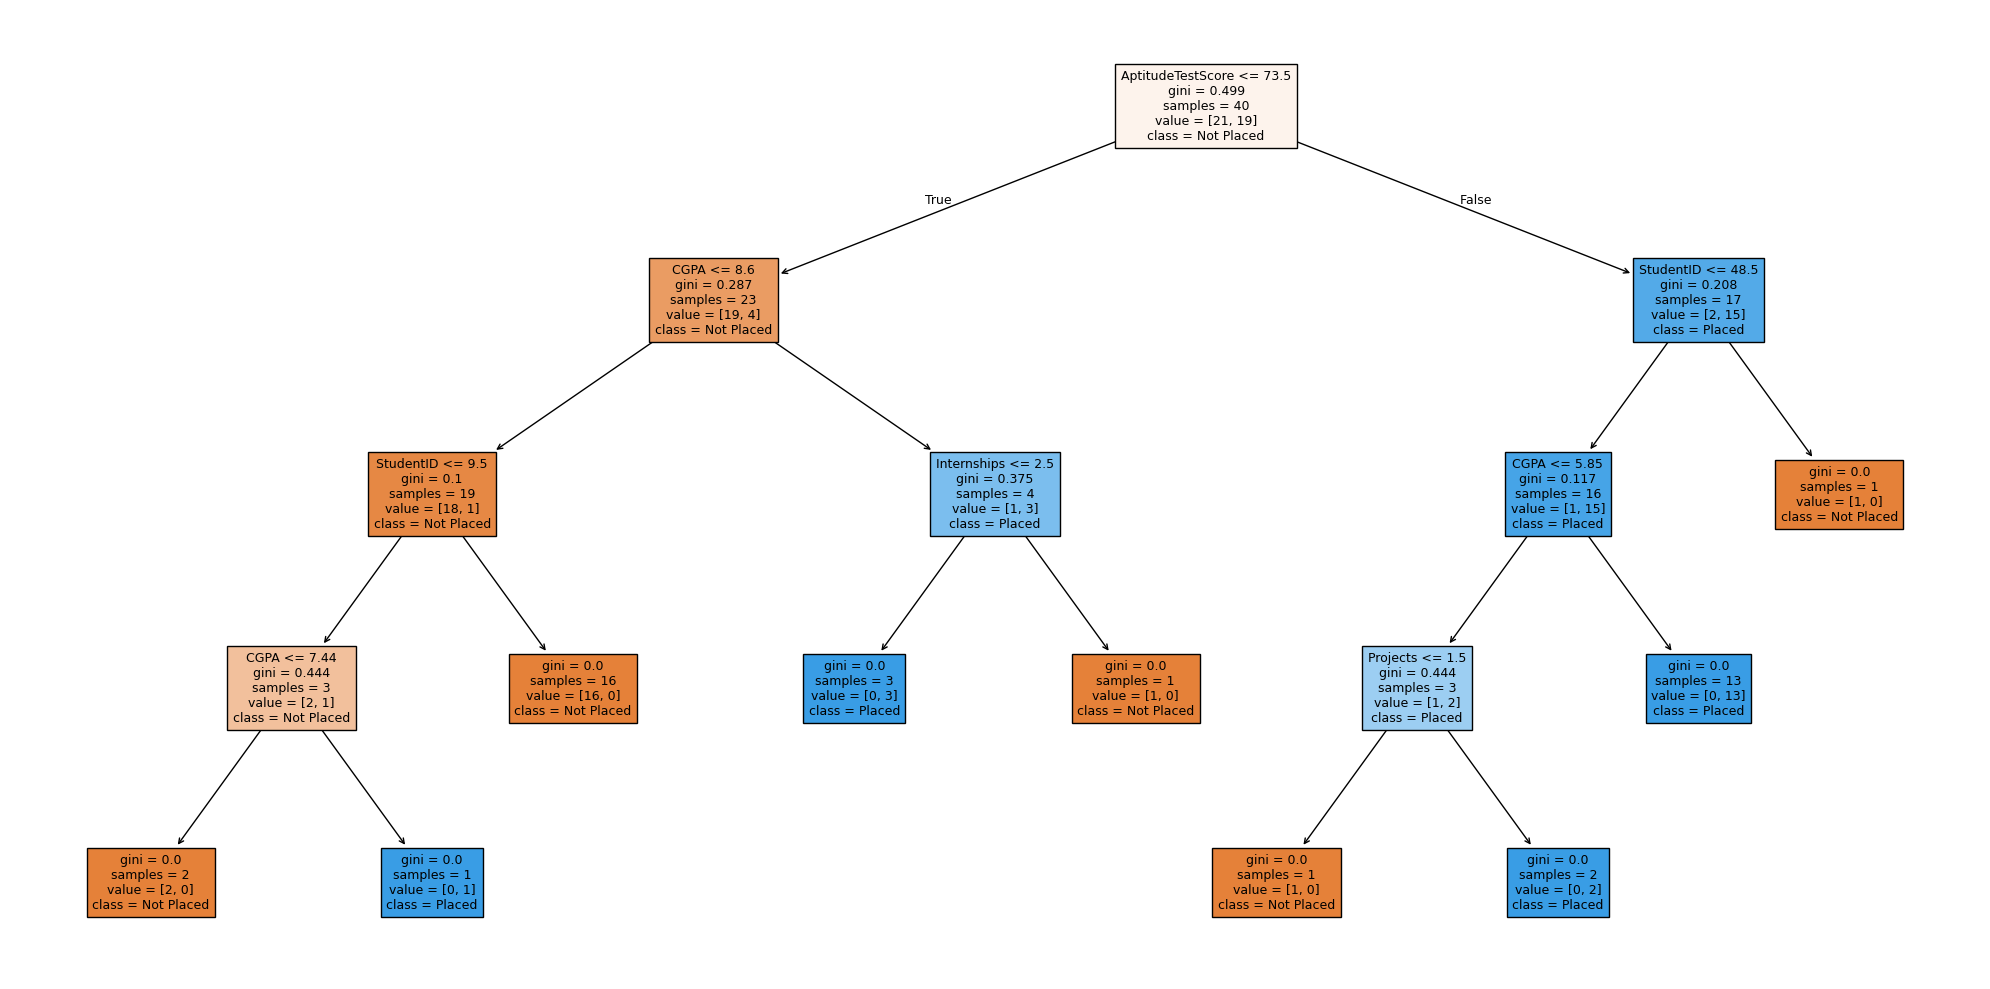

In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('simple_placement_dataset.csv')

# Display dataset information
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

# Fill missing values
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())

# Separate input and target
X = df.drop(columns=['Placed'])
y = df['Placed']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Decision Tree
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=9
)

plt.tight_layout()

# Save tree image
plt.savefig('decision_tree.png', dpi=150)

print("\nSaved tree image.")